# Week 9 Phase 1.15A — Physics–Residual Signal Audit

This notebook reads generated artifacts. It does **not** run a new acquisition trajectory.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_15a_physics_residual_signal_audit'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'P0_q20_AULC': 0.8424908088235294,
 'P1_minus_P0_q20_AULC': 0.0021323529411765296,
 'P1_path_rows': 8000,
 'P1_paths': 100,
 'P1_q20_AULC': 0.844623161764706,
 'conduction': 332,
 'current_head': '5a7a6c05ae5bf3191b74766156407211ad414360',
 'exact_branch_base': '5a7a6c05ae5bf3191b74766156407211ad414360',
 'historical_changes': [],
 'keyholes': 73,
 'outer_runs': 100,
 'phase114_decision': 'LATE_ACQUISITION_GAIN_ONLY',
 'phase114_parent_sha': '5a7a6c05ae5bf3191b74766156407211ad414360',
 'population': 405,
 'repeat_blocks': 20,
 'status': 'PASS'}

## 1. What is being separated?

H is the physics-only probability from the fitted log(h) latent mean. M3 contains that same mean plus an ARD Matérn GP correction. Their difference is a **nested correction diagnostic**, not committee disagreement.

In [2]:
display(json.loads((OUT/'pre_reveal_freeze.json').read_text()))
display(pd.read_csv(OUT/'correction_signal_summary.csv'))

{'columns': ['run_id',
  'repeat',
  'fold',
  'budget',
  'population_row_index',
  'P',
  'VX',
  'LS',
  'ST',
  'h',
  'p_H',
  'p_M3',
  'delta_p',
  'abs_delta_p',
  'physics_margin',
  'm3_margin',
  'residual_mean',
  'residual_std',
  'class_flip_H_to_M3',
  'correction_toward_keyhole',
  'correction_toward_conduction',
  'candidate_count',
  'score_inputs_are_pre_reveal_only'],
 'forbidden_columns_absent': True,
 'path': 'outputs/week9_phase1_15a_physics_residual_signal_audit/component_candidate_table.csv.gz',
 'rows': 285600,
 'sha256': '7ba079ccbb157e60522e836b9e286f7bfbb233a610bb647108441a92262408cb',
 'status': 'FROZEN_BEFORE_RETROSPECTIVE_JOIN'}

,metric,value,role
0,candidate_occurrences,285600.000000,descriptive
1,spearman_abs_correction_vs_M3_margin,-0.950643,descriptive; tests redundancy
2,spearman_A0_margin_score_vs_A1_product_score,0.983454,descriptive; tests acquisition duplication
3,A0_A1_same_top_candidate_fraction,0.374000,descriptive; no sequential replay
4,spearman_abs_correction_vs_physics_margin,-0.936625,descriptive
5,overall_fix_rate,0.000994,descriptive
6,overall_harm_rate,0.001159,descriptive
7,overall_net_fix_rate,-0.000165,descriptive
8,overall_class_flip_frequency,0.002153,descriptive


## 2. Do large corrections fix physics mistakes?

Truth is joined only after the score table is frozen.

,correction_quantile,candidate_occurrences,mean_abs_correction,H_accuracy,M3_accuracy,H_wrong_M3_correct,H_correct_M3_wrong,net_fix_rate,keyhole_prevalence,class_flip_frequency,q20_like_fraction,q30_like_fraction
0,Q1,57120,0.000002,0.993715,0.993715,0.000000,0.000000,0.000000,0.039793,0.000000,0.051155,0.092805
1,Q2,57120,0.000072,0.992595,0.992595,0.000000,0.000000,0.000000,0.150560,0.000000,0.085294,0.145991
2,Q3,57120,0.000788,0.971324,0.971324,0.000000,0.000000,0.000000,0.170466,0.000000,0.153606,0.237693
3,Q4,57120,0.005223,0.982616,0.982633,0.000053,0.000035,0.000018,0.148319,0.000088,0.159401,0.267700
4,Q5,57120,0.039710,0.944048,0.943207,0.004919,0.005760,-0.000840,0.248214,0.010679,0.396394,0.564496


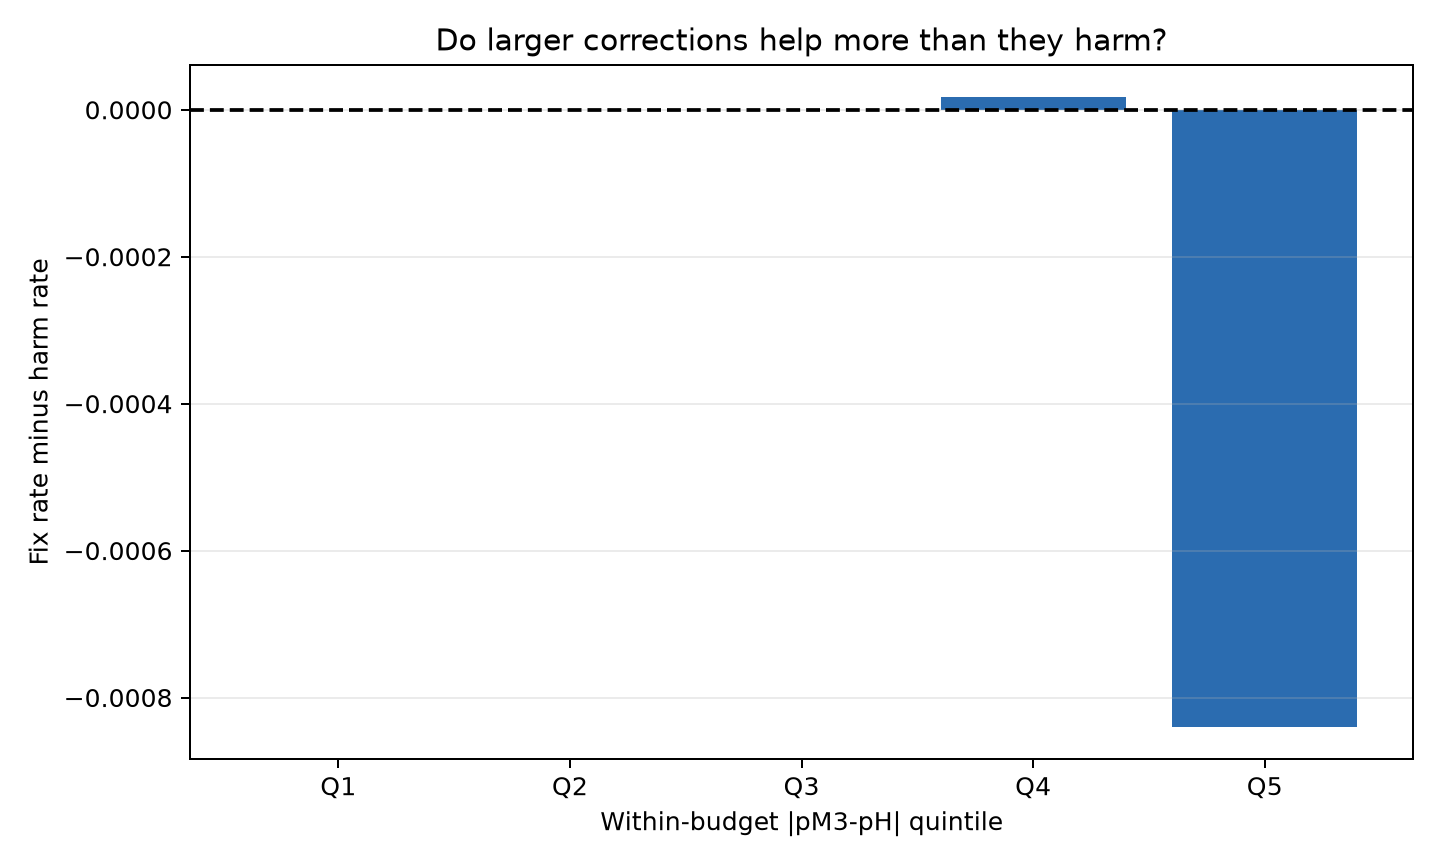

In [3]:
display(pd.read_csv(OUT/'correction_quantile_analysis.csv'))
display(Image(filename=str(OUT/'figures'/'01_correction_usefulness.png')))

## 3. Boundary relevance is retrospective

Fold B1/q20/q30 information never enters a proposed acquisition score.

,correction_quantile,mean_B1_distance,median_B1_distance,q20_like_fraction,q20_like_enrichment,q30_like_fraction,q30_like_enrichment,spearman_abs_correction_vs_B1_distance
0,Q1,1.864629,1.859667,0.051155,0.302391,0.092805,0.354572,0.185944
1,Q2,1.671752,1.656108,0.085294,0.504191,0.145991,0.557778,0.115948
2,Q3,1.519236,1.488614,0.153606,0.908000,0.237693,0.908136,0.067661
3,Q4,1.432758,1.371744,0.159401,0.942254,0.267700,1.022782,-0.208707
4,Q5,1.096837,1.067744,0.396394,2.343165,0.564496,2.156732,-0.317450


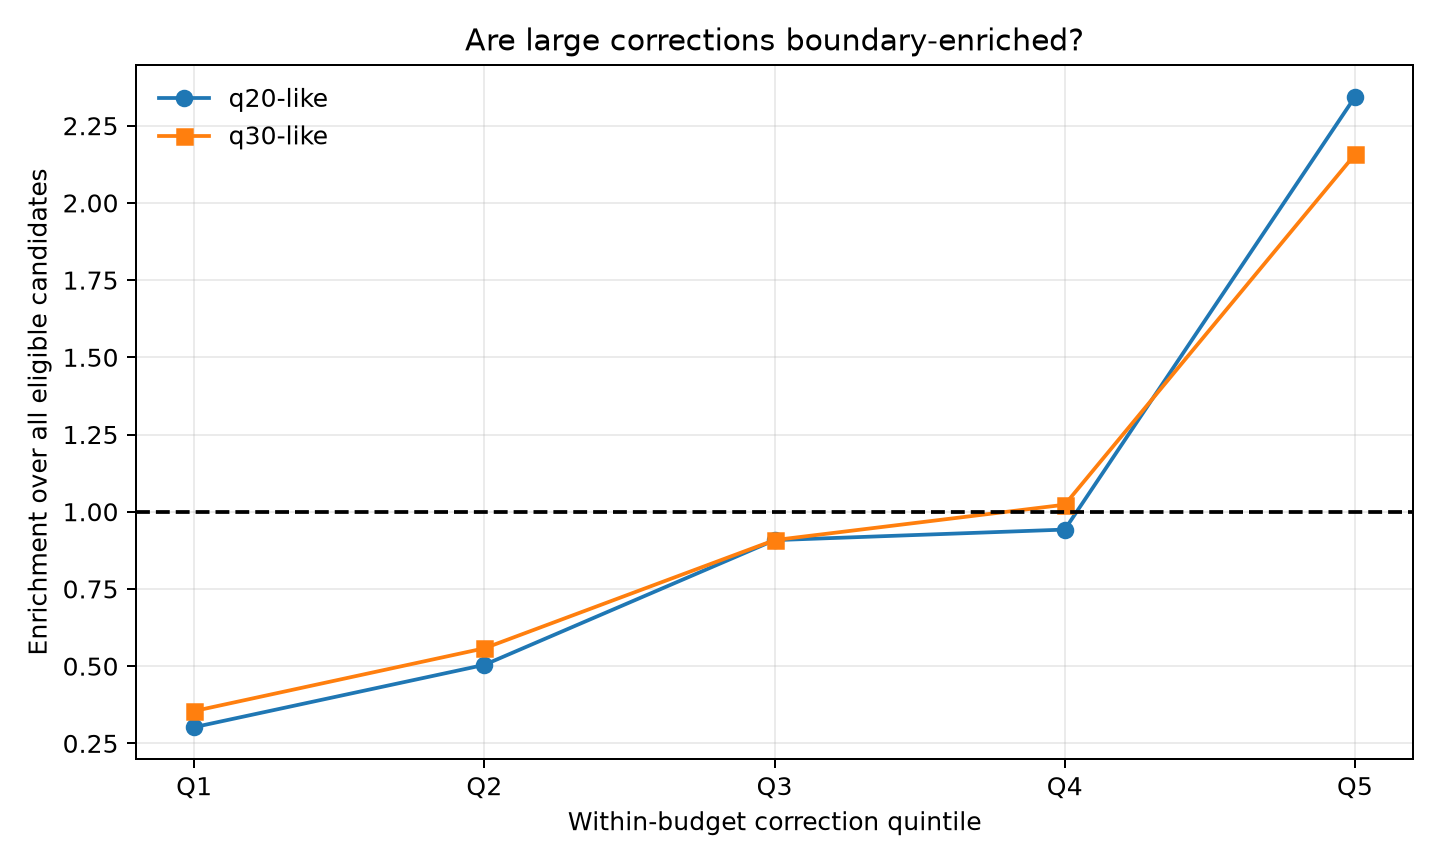

In [4]:
display(pd.read_csv(OUT/'boundary_enrichment_analysis.csv'))
display(Image(filename=str(OUT/'figures'/'02_boundary_enrichment.png')))

## 4. Keyhole/Conduction asymmetry and budget evolution

,budget_region,truth,candidate_occurrences,mean_delta_p,mean_abs_delta_p,toward_keyhole,class_flip_frequency,H_accuracy,M3_accuracy,fix_rate,harm_rate,net_fix_rate
0,B16_24,0,75808,0.004555,0.006191,0.750013,0.001860,0.975359,0.974660,0.000580,0.001280,-0.000699
1,B16_24,1,15392,-0.004443,0.014502,0.277092,0.010720,0.866619,0.867464,0.005782,0.004938,0.000845
2,B25_40,0,98126,0.006229,0.009890,0.605507,0.001773,0.990288,0.989778,0.000632,0.001141,-0.000510
3,B25_40,1,17874,-0.007987,0.022596,0.363321,0.007441,0.923296,0.925590,0.004867,0.002574,0.002294
4,B41_80,0,68406,0.002984,0.005919,0.552890,0.000000,0.996097,0.996097,0.000000,0.000000,0.000000
5,B41_80,1,9994,-0.007269,0.014412,0.367821,0.000200,0.990294,0.990494,0.000200,0.000000,0.000200


,budget_region,candidate_occurrences,mean_abs_delta_p,median_abs_delta_p,mean_residual_std,class_flip_frequency,H_accuracy,M3_accuracy,fix_rate,harm_rate,net_fix_rate,q20_like_fraction
0,B16_24,91200,0.007594,0.000019,0.506031,0.003355,0.957007,0.956568,0.001458,0.001897,-0.000439,0.204123
1,B25_40,116000,0.011848,0.000931,0.845072,0.002647,0.979966,0.979888,0.001284,0.001362,-0.000078,0.176672
2,B41_80,78400,0.007001,0.000844,0.828116,0.000026,0.995357,0.995383,0.000026,0.000000,0.000026,0.117411


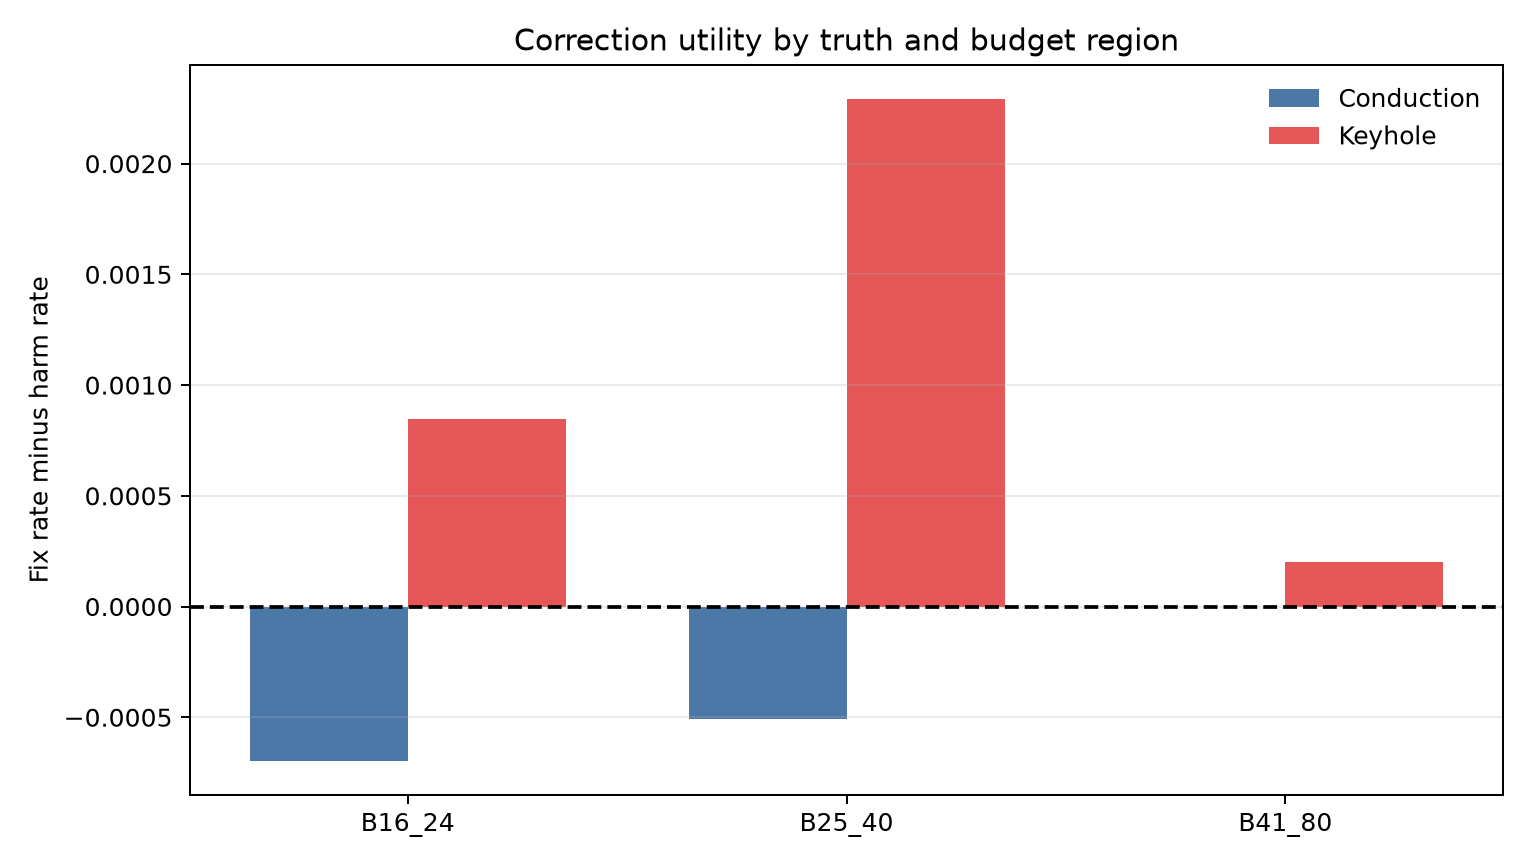

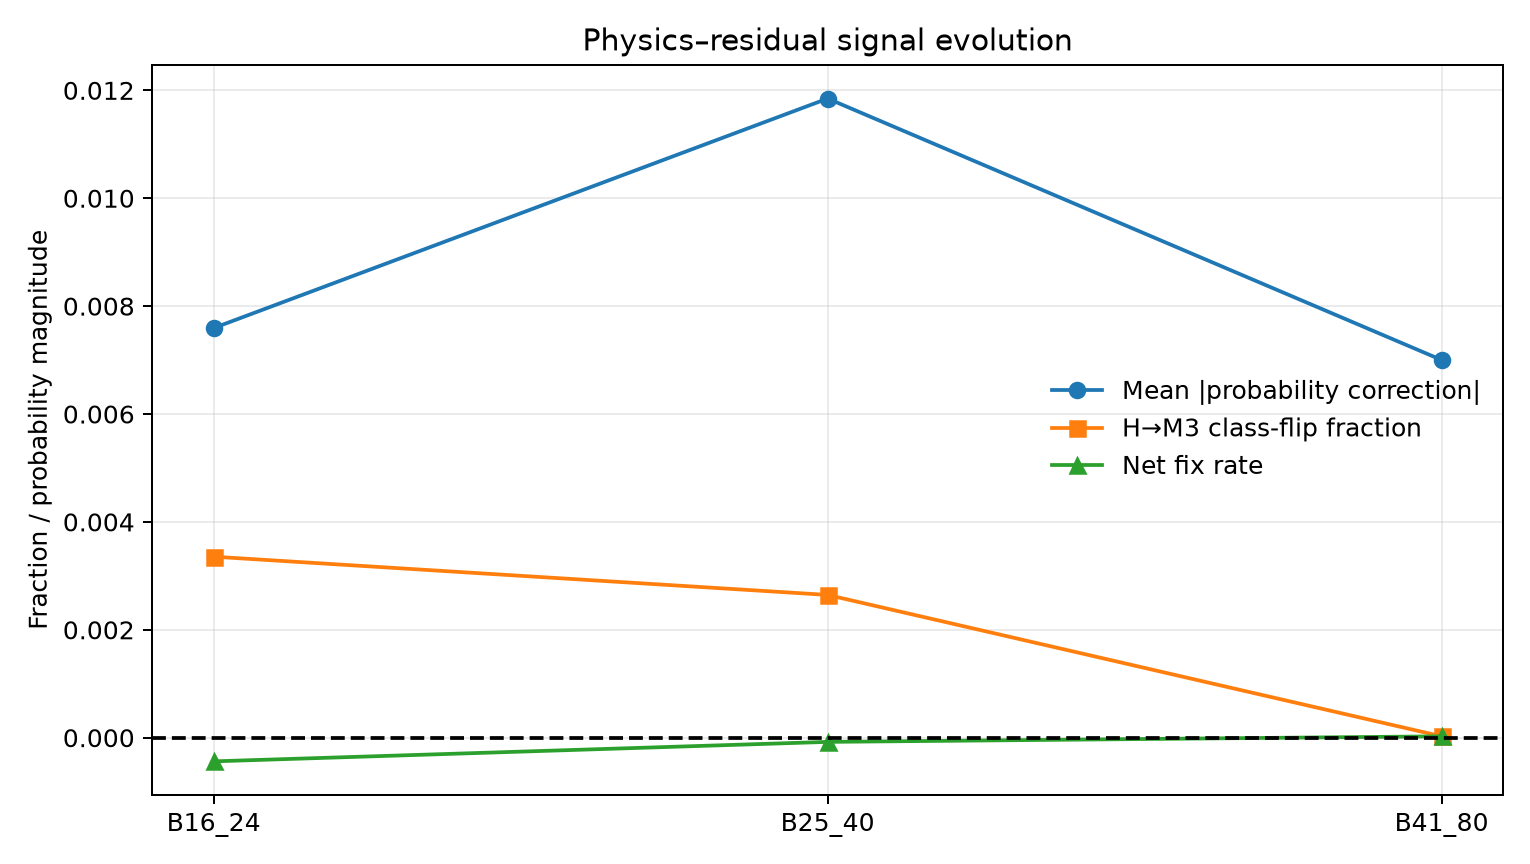

In [5]:
display(pd.read_csv(OUT/'keyhole_conduction_asymmetry.csv'))
display(pd.read_csv(OUT/'budget_evolution_summary.csv'))
display(Image(filename=str(OUT/'figures'/'03_class_budget_asymmetry.png')))
display(Image(filename=str(OUT/'figures'/'04_budget_evolution.png')))

## 5. Why did P1 temporarily lose q20 Keyhole recall at B40?

These are descriptive P1-versus-P0 path associations, not causal effects.

,budget,metric,P0_mean,P1_mean,P1_minus_P0,ci_lower,ci_upper
0,24,revealed_keyhole_fraction,0.393333,0.375000,-0.018333,-0.030000,-0.006250
1,24,active_query_keyhole_fraction,0.533750,0.478750,-0.055000,-0.091250,-0.018750
2,24,physics_log_h_coefficient,20.762438,56.920334,36.157896,16.290274,60.234837
3,24,residual_sd,0.711689,0.766142,0.054453,-0.013110,0.121673
4,24,residual_sd_upper_bound_hit,0.350000,0.580000,0.230000,0.130000,0.320000
...,...,...,...,...,...,...,...
60,40,q20_keyhole_mean_p_M3,0.710927,0.699809,-0.011119,-0.023161,0.001560
61,40,q20_keyhole_recall_H,0.745750,0.732230,-0.013520,-0.028675,0.001219
62,40,q20_keyhole_recall_M3,0.772440,0.748738,-0.023702,-0.043552,-0.003452
63,40,active_query_standardized_pairwise_spread,2.411076,2.257871,-0.153205,-0.199713,-0.108414


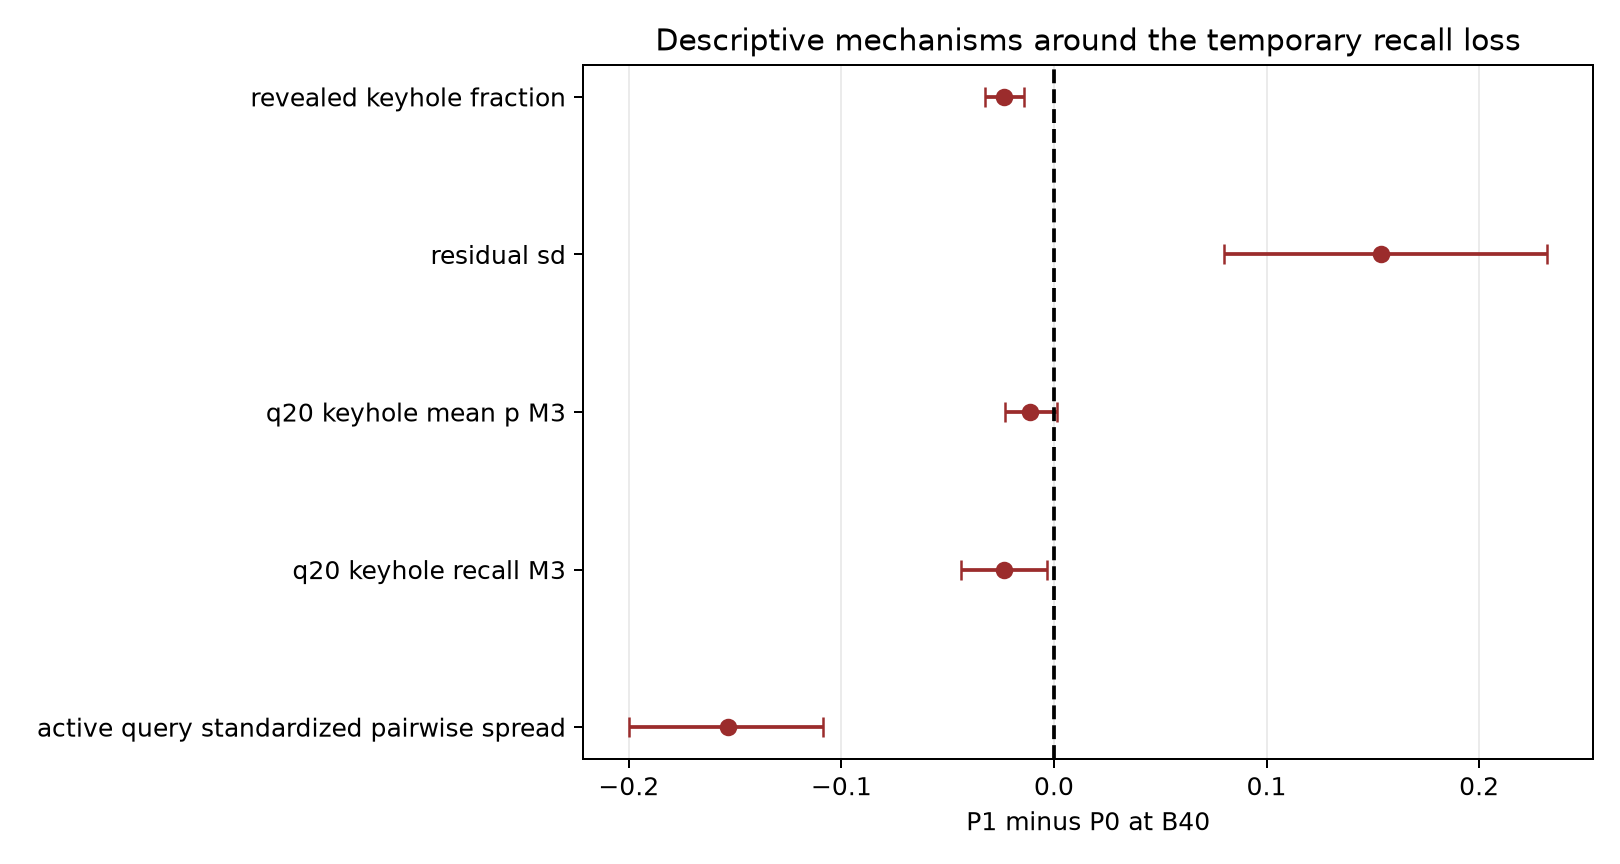

In [6]:
display(pd.read_csv(OUT/'b40_recall_mechanism_audit.csv'))
display(Image(filename=str(OUT/'figures'/'05_b40_mechanism.png')))

## 6. Numerical reliability

High bound-hit rates weaken mechanistic interpretation even when optimizer convergence and L100/L1000 sensitivity are acceptable.

In [7]:
display(pd.read_csv(OUT/'component_fit_diagnostics_summary.csv'))

,path,scope,metric,mean,median,n
0,P0,B40,residual_sd,0.807415,1.000000,100
1,P0,B40,residual_sd_upper_bound_hit,0.570000,1.000000,100
2,P0,B40,any_length_upper_bound_hit,0.830000,1.000000,100
3,P0,B40,optimizer_converged,0.980000,1.000000,100
4,P0,B40,anisotropy_ratio,985.843784,261.764160,100
5,P0,B40,l_P,36.150932,2.424867,100
6,P0,B40,l_VX,11.429168,0.421819,100
7,P0,B40,l_LS,47.378000,15.713550,100
8,P0,B40,l_ST,78.254836,100.000000,100
9,P0,all_selected,residual_sd,0.778760,0.981310,500


## 7. Literature and designs

In [8]:
display(pd.read_csv(OUT/'literature_comparison.csv'))
display(Markdown((OUT/'candidate_acquisition_designs.md').read_text()))

,paper,source,model,physics_information,discrepancy_or_residual,acquisition,task,boundary_target,similarity,difference
0,Gardner et al. (2021),https://doi.org/10.1016/j.ymssp.2020.107381,GP model-discrepancy regression with uncertain...,simulator predictions,yes,sampling-based discrepancy inference; not a se...,regression/calibration,no,explicit physics/model plus GP discrepancy,does not use classification correction magnitu...
1,"Yang, Chen & Wu (2025)",https://doi.org/10.1016/j.cma.2025.118198,physics model plus learned discrepancy in sequ...,convection-diffusion solver,yes,BED plus ensemble information-gain indicator f...,inverse problem/regression,no,actively learns discrepancy around a physics m...,information-gain BED with continuous measureme...
2,Polanska et al. (2026),https://arxiv.org/abs/2605.21348,neural operator,PDE residual,"physics residual, not GP correction to a prior...",query where PDE residual indicates weak physic...,operator regression,no,physics-residual signal guides acquisition,PDE residual and continuous fields rather than...
3,Hardcastle et al. (2025),https://doi.org/10.1039/D5DD00084J,GPC/GPR with physics-informed prior mean,CALPHAD or constraint prior,GP corrects informative prior,in-silico active refinement of phase diagrams/...,classification and threshold regression,yes,closest model/application analogue: physics pr...,does not establish this exact correction-magni...
4,Houlsby et al. (2011),https://arxiv.org/abs/1112.5745,Bayesian GP classification,none,no explicit physics discrepancy,BALD mutual information between label and para...,classification/preference learning,indirect,separates epistemic information from predictiv...,does not compare physics backbone with hybrid ...
5,Gotovos et al. (2013),https://people.csail.mit.edu/alkisg/files/goto...,GP level-set estimator,none,no,confidence-bound ambiguity near threshold,level-set classification,yes,canonical boundary-focused uncertainty design,no physics prior/correction term
6,Bryan & Schneider (2008),https://publications.ri.cmu.edu/actively-learn...,composite target from multiple observables,multiple model/data components,not a GP discrepancy decomposition,selects sample and observable for composite le...,level-set estimation,yes,acquisition can exploit structured components ...,"components are separately observable, unlike n..."


# Candidate acquisition designs

No trajectory was generated in Phase 1.15A. All quantities below are available before revealing a candidate label.

## A0 â€” frozen baseline

\[A_0(x)=1-2|p_{M3}(x)-0.5|.\]

Purpose: ordinary M3 classifier-margin uncertainty. It is parameter-free and remains the mandatory comparator. Its limitation is that it discards whether M3 materially corrected the physics prior.

## A1 â€” boundary-correction product

\[A_1(x)=\bigl(1-2|p_{M3}(x)-0.5|\bigr)\,|p_{M3}(x)-p_H(x)|.\]

Purpose: require both final boundary relevance and a material physics-to-M3 correction. No tuning parameter is present. It is closest in spirit to physics-residual acquisition (Polanska et al.) and discrepancy-aware design (Yang et al.), while retaining the classification-boundary gate of margin/LSE methods. Failure modes: large corrections can be confidently wrong; the product can ignore useful high-uncertainty points when the current residual is still small; repeated bound hits may distort correction magnitude.

## A2 â€” Keyhole-directed boundary correction

\[A_2(x)=\bigl(1-2|p_{M3}(x)-0.5|\bigr)\,\max\{p_{M3}(x)-p_H(x),0\}.\]

Purpose: test the specific Phase 1.14 early missed-Keyhole failure mode by prioritizing boundary candidates where the residual moves probability toward Keyhole. It has no tuned weight. Failure modes: it is deliberately asymmetric, may create false positives, and can miss important corrections toward Conduction. It should be a backup diagnostic, not the default recommendation.

## Recommendation

**No Phase 1.15B replay yet.** Decision: `CORRECTION_SIGNAL_PARTIAL`. Top-quintile net-fix CI lower bound is -0.0006; q20-like enrichment CI lower bound is 2.753; early net-fix CI lower bound is -0.0027. Under a partial result, boundary enrichment can be explained largely by ordinary margin redundancy and does not justify a new trajectory by itself. If stronger independent evidence appears later, A1 is the preferred simple rule; A2 remains a mechanism sensitivity only.


## 8. Safe conclusion

In [9]:
display(Markdown((OUT/'SUPERVISOR_PHASE1_15A_ONE_PAGE.md').read_text()))

# Supervisor Phase 1.15A â€” one page

**Decision:** `CORRECTION_SIGNAL_PARTIAL`

- Reconstructed the H and M3 components at ten budgets on the already-published P1 path; no new active-learning trajectory was run.
- Large-correction Q5: fix 0.005, harm 0.006, net -0.001; repeat CI [-0.001, +0.001].
- Pooled Q5 q20-like enrichment 2.34Ã—; mean per-run 2.92Ã—, repeat CI [2.75, 3.09].
- Correction magnitude is highly redundant with margin (rho -0.95); early Q5 net-fix CI [-0.003, +0.006].
- At B40, P1âˆ’P0 q20-Keyhole mean M3 probability -0.011 and recall -0.024; descriptive, not causal.
- Numerical pressure remains high (residual upper-hit 66%, length upper-hit 75%), although convergence is 96% and L1000 sensitivity was locally stable.
- Future replay recommendation: **No Phase 1.15B replay yet**. A1 remains a simple design only if later evidence separates correction value from ordinary margin.

Closest literature already covers active discrepancy learning and physics-informed prior-mean GP active learning; any novelty possibility is narrow and unresolved.
